In [5]:
# Step 1 — Import libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel('crop_yield_india^.csv.xlsx')

# Quick check
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Preview
df.head()

Shape: (49999, 10)

Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Temperature', 'Humidity', 'Soil_Moisture', 'Area', 'Production']

Data Types:
 State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Temperature        int64
Humidity           int64
Soil_Moisture      int64
Area             float64
Production       float64
dtype: object

Missing Values:
 State_Name         0
District_Name      0
Crop_Year          0
Season             0
Crop               0
Temperature        0
Humidity           0
Soil_Moisture      0
Area               0
Production       215
dtype: int64


,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0


In [6]:
# Step 2A — Basic statistics
print("Dataset Shape:", df.shape)
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (49999, 10)

Basic Statistics:


,Crop_Year,Temperature,Humidity,Soil_Moisture,Area,Production
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,4.978400e+04
mean,2005.879138,34.445489,44.776116,53.110502,7363.389469,4.132019e+05
std,5.106092,3.498524,6.662406,5.258764,27927.935789,1.232609e+07
min,1997.000000,25.000000,35.000000,45.000000,0.200000,0.000000e+00
25%,2002.000000,34.000000,40.000000,50.000000,76.000000,8.700000e+01
50%,2006.000000,36.000000,42.000000,54.000000,436.000000,6.384400e+02
75%,2010.000000,36.000000,50.000000,55.000000,2546.500000,5.615000e+03
max,2014.000000,37.000000,55.000000,62.000000,877029.000000,7.801620e+08


In [7]:
# Step 2B — Create target variable
df['Yield'] = df['Production'] / df['Area']

# Remove infinite and null values created by division
df.replace([float('inf'), -float('inf')], float('nan'), inplace=True)
df.dropna(inplace=True)

print("Shape after cleaning:", df.shape)
print("\nYield column added. Sample values:")
print(df['Yield'].describe())

Shape after cleaning: (49784, 11)

Yield column added. Sample values:
count    49784.000000
mean        84.233237
std        929.707033
min          0.000000
25%          0.616852
50%          1.053023
75%          2.876939
max      33089.005477
Name: Yield, dtype: float64


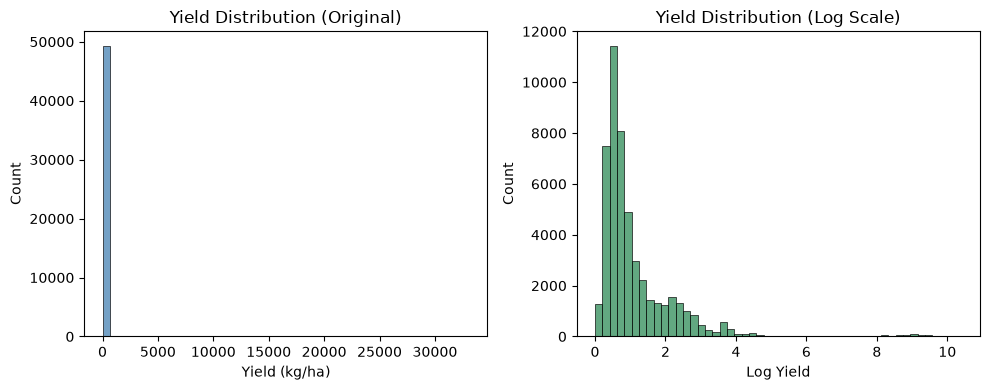

In [8]:
# Step 2C — Yield distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Yield'], bins=50, color='steelblue')
plt.title('Yield Distribution (Original)')
plt.xlabel('Yield (kg/ha)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['Yield']), bins=50, color='seagreen')
plt.title('Yield Distribution (Log Scale)')
plt.xlabel('Log Yield')

plt.tight_layout()
plt.show()

C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\1460209092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='Greens_r')


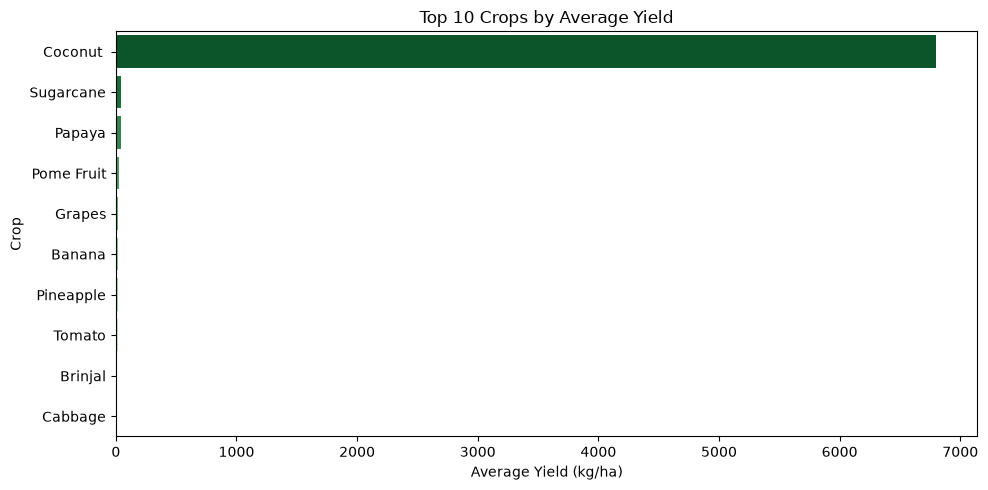

In [9]:
# Step 2D — Top 10 crops by average yield
plt.figure(figsize=(10, 5))
top_crops = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_crops.values, y=top_crops.index, palette='Greens_r')
plt.title('Top 10 Crops by Average Yield')
plt.xlabel('Average Yield (kg/ha)')
plt.tight_layout()
plt.show()

C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\609885593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='Blues_r')


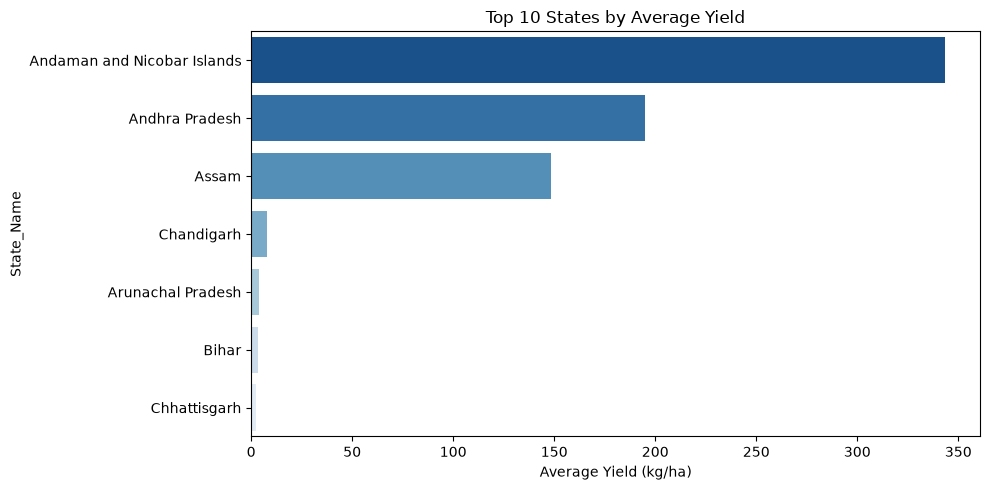

In [10]:
# Step 2E — Top 10 states by average yield
plt.figure(figsize=(10, 5))
top_states = df.groupby('State_Name')['Yield'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.values, y=top_states.index, palette='Blues_r')
plt.title('Top 10 States by Average Yield')
plt.xlabel('Average Yield (kg/ha)')
plt.tight_layout()
plt.show()

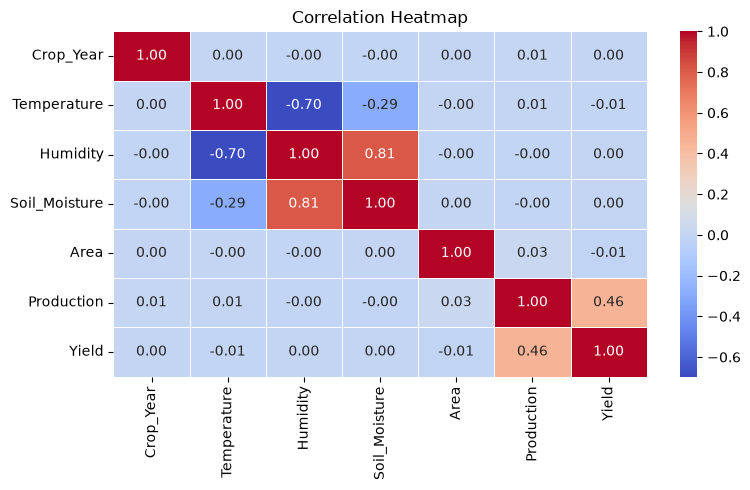

In [11]:
# Step 2F — Correlation heatmap
plt.figure(figsize=(8, 5))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\3173829055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield', data=df, palette='Set2')


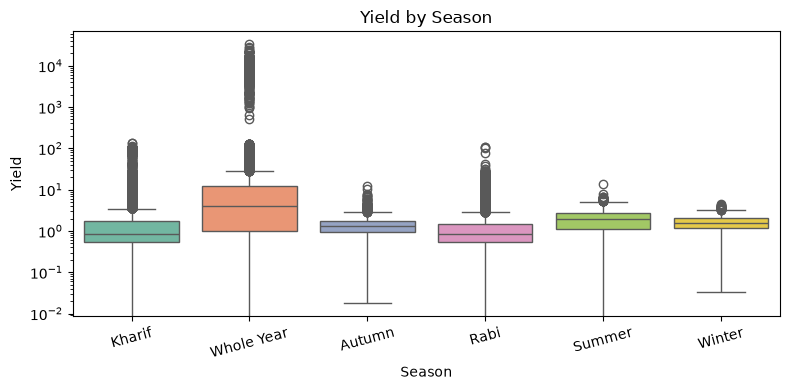

In [12]:
# Step 2G — Season wise yield
plt.figure(figsize=(8, 4))
df['Season'] = df['Season'].str.strip()  # remove extra spaces
sns.boxplot(x='Season', y='Yield', data=df, palette='Set2')
plt.title('Yield by Season')
plt.yscale('log')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [13]:
# Step 3A — Label Encoding categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['State_Name', 'District_Name', 'Crop', 'Season']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done!")
print(df.head())

Encoding done!
   State_Name  District_Name  Crop_Year  Season  Crop  Temperature  Humidity  \
0           0             78       2000       1     0           36        35   
1           0             78       2000       1    46           37        40   
2           0             78       2000       1    59           36        41   
3           0             78       2000       4     3           37        42   
4           0             78       2000       4    12           36        40   

   Soil_Moisture    Area  Production     Yield  
0             45  1254.0      2000.0  1.594896  
1             46     2.0         1.0  0.500000  
2             50   102.0       321.0  3.147059  
3             55   176.0       641.0  3.642045  
4             54   720.0       165.0  0.229167  


In [14]:
# Step 3B — Log transform the target variable to reduce skew
df['Yield'] = np.log1p(df['Yield'])

print("Log transform applied to Yield")
print(df['Yield'].describe())

Log transform applied to Yield
count    49784.000000
mean         1.127343
std          1.144920
min          0.000000
25%          0.480481
50%          0.719313
75%          1.355046
max         10.406987
Name: Yield, dtype: float64


In [15]:
# Step 3C — Define X (features) and y (target)
X = df.drop(columns=['Yield', 'Production'])
y = df['Yield']

print("Features:", X.columns.tolist())
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Features: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Temperature', 'Humidity', 'Soil_Moisture', 'Area']
Feature shape: (49784, 9)
Target shape: (49784,)


In [16]:
# Step 3D — Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

Training size: (39827, 9)
Testing size : (9957, 9)


In [17]:
# Step 3E — Feature scaling (needed for KNN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print("Sample scaled values:", X_train_scaled[0])

Scaling done!
Sample scaled values: [ 0.60103484  0.3888945  -0.55945975 -0.17028413  1.51106703  0.16359054
  0.77942591  1.11982764  1.15473209]


In [18]:
# Step 4A — Import all models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [19]:
# Step 4B — Train and compare all 4 models
results = {}

models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN'               : KNeighborsRegressor(n_neighbors=5)
}

for name, model in models.items():
    # KNN uses scaled data, others use original
    if name == 'KNN':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)

    results[name] = {'R2': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
    print(f"{name:20s} | R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

print("\nAll models trained successfully!")

Linear Regression    | R²: 0.1426 | RMSE: 1.0713 | MAE: 0.6794
Decision Tree        | R²: 0.9267 | RMSE: 0.3133 | MAE: 0.1914
Random Forest        | R²: 0.9742 | RMSE: 0.1858 | MAE: 0.1045
KNN                  | R²: 0.3337 | RMSE: 0.9444 | MAE: 0.5266

All models trained successfully!


In [20]:

# Step 4C — Show results as DataFrame table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)
print("\nModel Comparison (sorted by R²):")
results_df


Model Comparison (sorted by R²):


,R2,RMSE,MAE
Random Forest,0.9742,0.1858,0.1045
Decision Tree,0.9267,0.3133,0.1914
KNN,0.3337,0.9444,0.5266
Linear Regression,0.1426,1.0713,0.6794


C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\2148038951.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(results_df.index, rotation=15, ha='right')
C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\2148038951.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(results_df.index, rotation=15, ha='right')
C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\2148038951.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(results_df.index, rotation=15, ha='right')


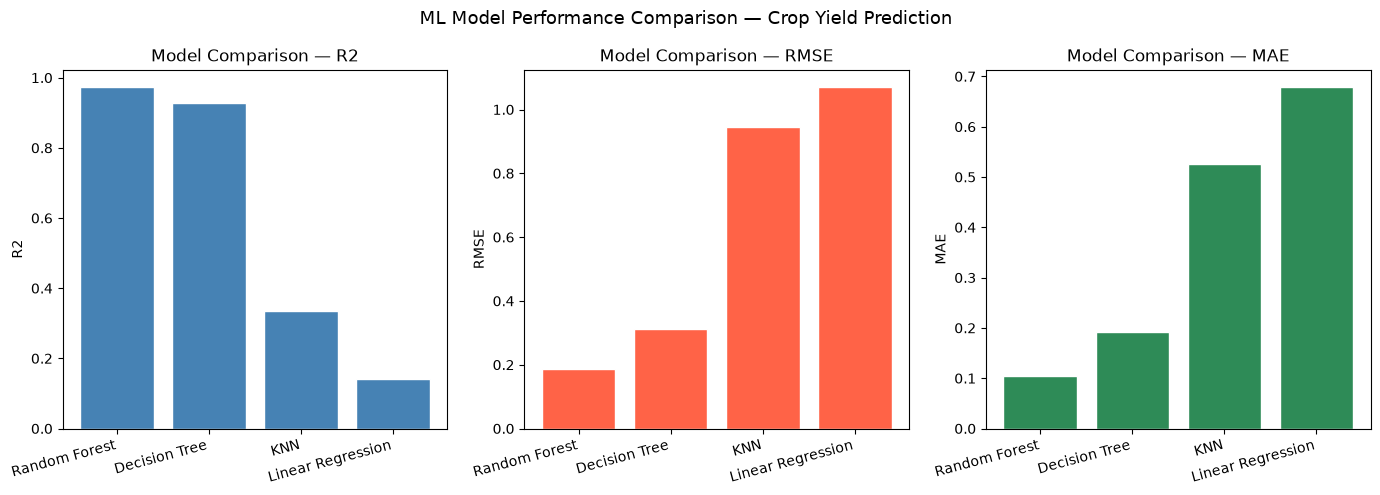

In [21]:
# Step 4D — Bar chart comparing all models
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['R2', 'RMSE', 'MAE']
colors  = ['steelblue', 'tomato', 'seagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].bar(results_df.index, results_df[metric], color=color, edgecolor='white')
    axes[i].set_title(f'Model Comparison — {metric}')
    axes[i].set_xticklabels(results_df.index, rotation=15, ha='right')
    axes[i].set_ylabel(metric)

plt.suptitle('ML Model Performance Comparison — Crop Yield Prediction', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# Step 4E — Save the best model (Random Forest)
import pickle

best_model = models['Random Forest']

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as rf_model.pkl")
print("Scaler saved as scaler.pkl")

Model saved as rf_model.pkl
Scaler saved as scaler.pkl


In [23]:
# Step 5A — Extract feature importance
feature_names = X.columns.tolist()
importances   = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importance Scores:")
print(importance_df)

Feature Importance Scores:
         Feature  Importance
4           Crop    0.664818
3         Season    0.168515
0     State_Name    0.077099
2      Crop_Year    0.053919
8           Area    0.019646
1  District_Name    0.010510
7  Soil_Moisture    0.002204
5    Temperature    0.001748
6       Humidity    0.001540


C:\Users\Shoma Kumari\AppData\Local\Temp\ipykernel_18632\1342494262.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='YlGn_r')


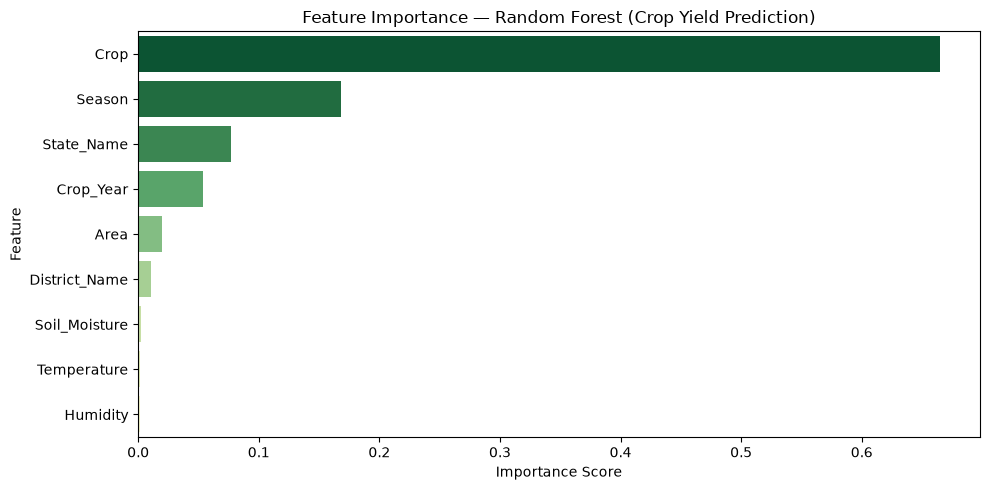

In [24]:
# Step 5B — Feature importance bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='YlGn_r')
plt.title('Feature Importance — Random Forest (Crop Yield Prediction)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

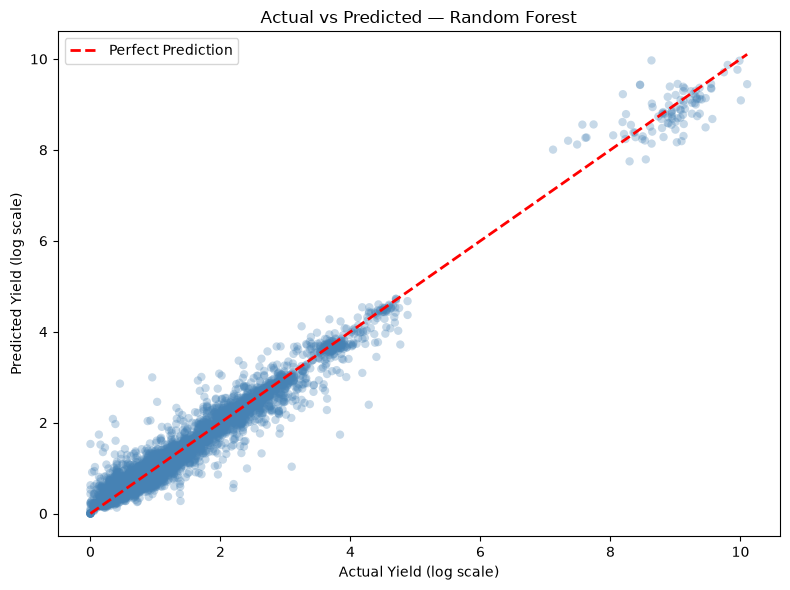

In [25]:
# Step 5C — Actual vs Predicted (Random Forest)
rf_preds = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Yield (log scale)')
plt.ylabel('Predicted Yield (log scale)')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

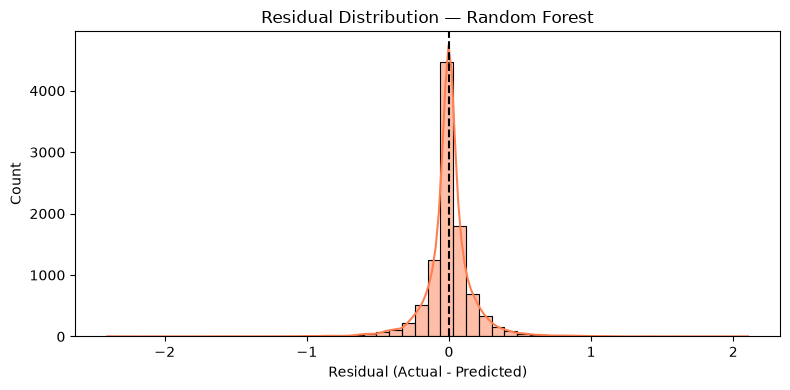

In [26]:
# Step 5D — Residual plot
residuals = y_test - rf_preds

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Residual Distribution — Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [27]:
# Step 5E — Final project summary
print("=" * 55)
print("   CROP YIELD PREDICTION — PROJECT SUMMARY")
print("=" * 55)
print(f"\nDataset size      : {df.shape[0]:,} records")
print(f"Features used     : {X.shape[1]}")
print(f"Train size        : {X_train.shape[0]:,} rows")
print(f"Test size         : {X_test.shape[0]:,} rows")
print("\nModel Performance (R² Score):")
for model_name, scores in results.items():
    bar = '█' * int(scores['R2'] * 20)
    print(f"  {model_name:20s} {bar} {scores['R2']}")
print("\nBest Model        : Random Forest")
print(f"Best R² Score     : {results['Random Forest']['R2']}")
print(f"Best RMSE         : {results['Random Forest']['RMSE']}")
print(f"\nTop Feature       : {importance_df.iloc[0]['Feature']}")
print(f"2nd Feature       : {importance_df.iloc[1]['Feature']}")
print(f"3rd Feature       : {importance_df.iloc[2]['Feature']}")
print("\nModel saved to    : rf_model.pkl")
print("=" * 55)
print("Project complete! Ready for Streamlit app (Step 6)")
print("=" * 55)

   CROP YIELD PREDICTION — PROJECT SUMMARY

Dataset size      : 49,784 records
Features used     : 9
Train size        : 39,827 rows
Test size         : 9,957 rows

Model Performance (R² Score):
  Linear Regression    ██ 0.1426
  Decision Tree        ██████████████████ 0.9267
  Random Forest        ███████████████████ 0.9742
  KNN                  ██████ 0.3337

Best Model        : Random Forest
Best R² Score     : 0.9742
Best RMSE         : 0.1858

Top Feature       : Crop
2nd Feature       : Season
3rd Feature       : State_Name

Model saved to    : rf_model.pkl
Project complete! Ready for Streamlit app (Step 6)
